## Setup & Initialization

In [1]:
import os
import yaml
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import ultralytics


print("Ultralytics Environment Checks:")
ultralytics.checks()


DATA_ROOT = os.path.abspath(r'C:/id_card/Data')
UNIFIED_DIR = os.path.join(DATA_ROOT, 'Unified_Dataset')

Ultralytics 8.4.84  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Setup complete  (28 CPUs, 15.7 GB RAM, 382.9/951.6 GB disk)


## Hyperparameter Tuning

In [ ]:
print("Initializing YOLOv8 Nano for FOCUSED tuning...")
model = YOLO('yolov8n.pt') 

tuning_results = model.tune(
    data=r'C:/id_card/Data/Unified_Dataset_2_3_v2/unified_data.yaml',
    epochs=8,          
    iterations=15,      # Reduced to 15 because we are testing fewer variables
    optimizer='SGD',    
    device=0,           
    imgsz=640,          
    batch=16,            
    
    # ------------------------------------------------
    # THE LOCKDOWN: YOLO WILL NOT TUNE THESE
    # ------------------------------------------------
    fliplr=0.0,         
    hsv_h=0.0,          
    hsv_s=0.0,          
    hsv_v=0.0,          
    degrees=0.0,         
    shear=0.0,          
    perspective=0.0,    
   
    
    plots=False,        
    save=False          
)

print("\n Focused Tuning complete!")

Initializing YOLOv8 Nano for FOCUSED tuning on RTX 5060...
Tuner: Initialized Tuner instance with 'tune_dir=C:\id_card\runs\detect\tune'
Tuner:  Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/15 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'cls_pw': 0.0, 'dfl': 1.5, 'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.0, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.0, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved C:\id_card\runs\detect\tune\tune_scatter_plots.png
Saved C:\id_card\runs\detect\tune\tune_fitness.png

Tuner: 1/15 iterations complete  (254.10s)
Tuner: Results saved to C:\id_card\runs\detect\tune
Tuner: Best fitness=0.61069 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precisio

# Traning Differnt model

#### Traning Yolov8n with the best hyperparameters found from tuning 

In [3]:
print("Initializing upgraded YOLOv8 nano model for final training...")
model = YOLO('yolov8n.pt') 

final_results = model.train(
    data=r'C:/id_card/Data/Unified_Dataset_2_3_v2/unified_data.yaml',  
    epochs=100,    
    patience=25,
    imgsz=800, 
    batch=16,
    device=0, 
    workers=0,               
   
    cfg=r'C:/id_card/runs/detect/tune/best_hyperparameters.yaml', # load the best hyperparameters from tuning
    optimizer='SGD',        # Use SGD optimizer for final training
    cos_lr=True ,           #
    
    
    project='ID_Card_Detection',
    name='multi_class_final_nano',
    save=True
    
)

print("\n Final Training completed!")

Initializing upgraded YOLOv8 nano model for final training...
New https://pypi.org/project/ultralytics/8.4.87 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.84  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.00762, box=8.73505, cache=False, cfg=C:/id_card/runs/detect/tune/best_hyperparameters.yaml, classes=None, close_mosaic=10, cls=0.74915, cls_pw=0.00587, compile=False, conf=None, copy_paste=0.00826, copy_paste_mode=flip, cos_lr=True, cutmix=0.0004, data=C:/id_card/Data/Unified_Dataset_2_3_v2/unified_data.yaml, degrees=0.00162, deterministic=True, device=0, dfl=1.44801, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.00459, flipud=0.00335, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01006, hsv_s=7e-05, hsv_

#### Validation

In [2]:
best_model = YOLO("C:/id_card/runs/detect/ID_Card_Detection/multi_class_final_nano/weights/best.pt")

metrics = best_model.val(device='0')

print("\n--- Final Validation Metrics ---")
print(f"mAP50-95 : {metrics.box.map:.4f}")  # mean Average Precision at IoU thresholds from 0.5 to 0.95
print(f"mAP50    : {metrics.box.map50:.4f}") # mean Average Precision at IoU threshold of 0.5

Ultralytics 8.4.84  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 86.016.9 MB/s, size: 52.5 KB)
val: Scanning C:\id_card\Data\Unified_Dataset_2_3_v2\valid\labels.cache... 112 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 43, len(boxes) = 760. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.5it/s 2.8s0.3ss
                   all        112        760        0.9      0.873      0.886      0.745
        aadhaar number         58         58      0.994          1      0.995      0.856
           aad

#### Training Yolov8s model with the best hyperparameters from tuning

In [4]:
print("Initializing upgraded YOLOv8 Small model for final training...")
# UPGRADE: Moving to the 'Small' architecture for higher capacity
model = YOLO('yolov8s.pt') 

final_results = model.train(
    data=r'C:/id_card/Data/Unified_Dataset_2_3_v2/unified_data.yaml',  
    epochs=100,             # Full training cycle
    patience=25,            # Give it plenty of time to overcome plateaus
    imgsz=800,              # High resolution for tiny text
    batch=16,               # Utilizing your RTX 5060 efficiently
    device=0, 
    workers=0,              
    
    # ------------------------------------------------
    # LOAD THE WINNING RECIPE
    # ------------------------------------------------
    # Point this path to the yaml file generated by your tuning session
    cfg=r'C:/id_card/runs/detect/tune/best_hyperparameters.yaml',
    optimizer='SGD',        # Use SGD optimizer for final training
    cos_lr=True ,  
    
    project='ID_Card_Detection',
    name='multi_class_final_small',
    save=True
)

print("\n✅ Final Training completed!")

Initializing upgraded YOLOv8 Small model for final training...
New https://pypi.org/project/ultralytics/8.4.87 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.84  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.00762, box=8.73505, cache=False, cfg=C:/id_card/runs/detect/tune/best_hyperparameters.yaml, classes=None, close_mosaic=10, cls=0.74915, cls_pw=0.00587, compile=False, conf=None, copy_paste=0.00826, copy_paste_mode=flip, cos_lr=True, cutmix=0.0004, data=C:/id_card/Data/Unified_Dataset_2_3_v2/unified_data.yaml, degrees=0.00162, deterministic=True, device=0, dfl=1.44801, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.00459, flipud=0.00335, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01006, hsv_s=7e-05, hsv

#### Validation

In [5]:
best_model = YOLO(r'C:/id_card/runs/detect/ID_Card_Detection/multi_class_final_small/weights/best.pt')

metrics = best_model.val(device='cpu')

print("\n--- Final Validation Metrics ---")
print(f"mAP50-95 : {metrics.box.map:.4f}")
print(f"mAP50    : {metrics.box.map50:.4f}")

Ultralytics 8.4.84  Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Core i7-14700HX)
Model summary (fused): 73 layers, 11,135,646 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 778.7179.4 MB/s, size: 53.7 KB)
val: Scanning C:\id_card\Data\Unified_Dataset_2_3_v2\valid\labels.cache... 112 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 43, len(boxes) = 760. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3s/it 16.1s2.6s
                   all        112        760      0.905      0.895      0.893      0.763
        aadhaar number         58         58      0.991          1      0.995      0.887
           aadhar_card         58  

## Sample

use yolov8s model for the samples

In [ ]:

def analyze_id_card(image_path, weights_path):
    if not os.path.exists(image_path):
        print(f"Error: Could not find image at {image_path}")
        return
        
    if not os.path.exists(weights_path):
        print(f"Error: Could not find model weights at {weights_path}")
        return

    print("Loading model...")
    # Load your trained best.pt model
    model = YOLO(weights_path)
    
    # Read the image manually with cv2
    img_array = cv2.imread(image_path)
    

    print("Analyzing document...")
    predictions = model.predict(source=img_array, conf=0.5, iou=0.45, save=True, device='0')
    
    # Define our master card types
    card_types = ['aadhar_card', 'pan_card', 'dl_card']
    
    detected_card = "Unknown Document"
    extracted_fields = []
    
    for result in predictions:
        # Loop through every bounding box the model found
        for box in result.boxes:
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]
            confidence = float(box.conf[0])
            
            # Check if this bounding box is one of our full-card triggers
            if class_name in card_types:
                detected_card = class_name.replace('_', ' ').title()
            else:
                # Otherwise, it's a specific field on the card
                extracted_fields.append(f"{class_name} (Confidence: {confidence:.2f})")
        
        # Generate the image with drawn bounding boxes
        annotated_img = result.plot()
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        # --- Print the cleanly formatted results ---
        print("\n" + "="*45)
        print(f"🔍 DOCUMENT IDENTIFIED: {detected_card}")
        print("="*45)
        
        if extracted_fields:
            print("Fields Detected:")
            for field in extracted_fields:
                print(f"  • {field}")
        else:
            print("  • No distinct fields detected above the 50% confidence threshold.")
        print("="*45 + "\n")
        
        # --- Display the Image ---
        plt.figure(figsize=(10, 10))
        plt.imshow(annotated_img_rgb)
        plt.axis('off')
        plt.title(f"YOLOv8 Analysis: {detected_card}")
        plt.show()

# Put the path to your newly trained weights here
MY_WEIGHTS = r"C:/id_card/runs/detect/ID_Card_Detection/multi_class_final_nano/weights/best.pt"

# Put the path to ANY image you want to test here
TEST_IMAGE = r"C:/id_card/Data/Detection.v1i.yolov8/test/images/KYC_NEW-2F6001010805-2F_pan_png.rf.83cb1c8094f9ea1c50b81d1ddbddb61c.jpg"

# Run the analysis!
analyze_id_card(TEST_IMAGE, MY_WEIGHTS)

Loading model...
Analyzing document...

0: 800x800 1 dob, 1 father, 1 name, 1 pan number, 1 pan_card, 1 pancard, 14.2ms
Speed: 6.3ms preprocess, 14.2ms inference, 1.3ms postprocess per image at shape (1, 3, 800, 800)
Results saved to C:\id_card\runs\detect\predict

🔍 DOCUMENT IDENTIFIED: Pan Card
Fields Detected:
  • father (Confidence: 0.96)
  • name (Confidence: 0.96)
  • pan number (Confidence: 0.93)
  • pancard (Confidence: 0.90)
  • dob (Confidence: 0.81)



<Figure size 1000x1000 with 1 Axes>

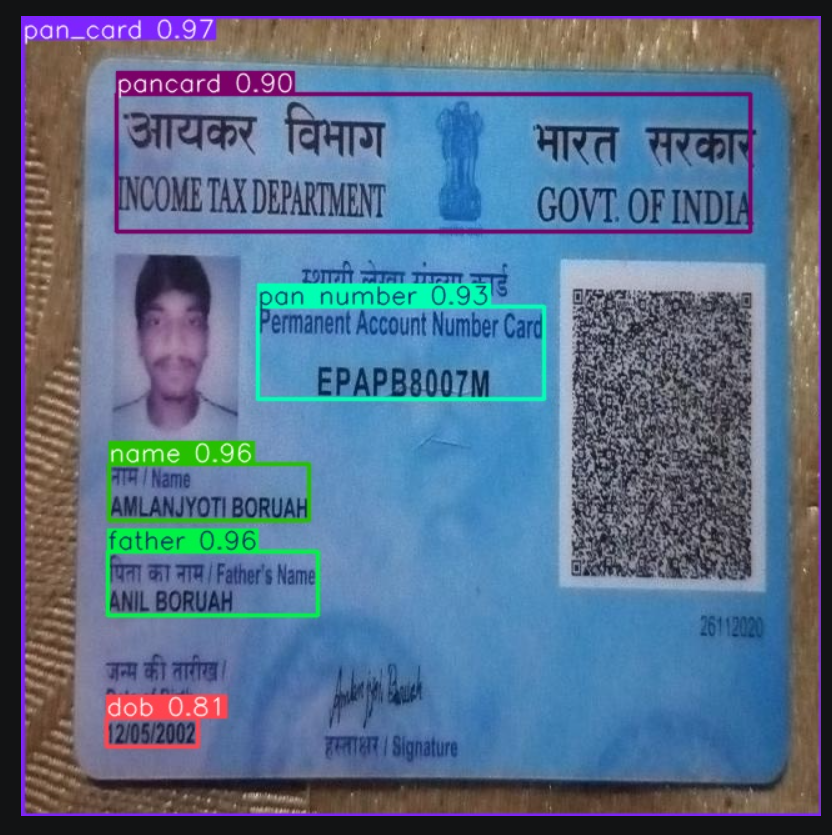

In [8]:
# Put the path to ANY image you want to test here
TEST_IMAGE = r"Data/Detection.v1i.yolov8/test/images/IPPBAND00783_aadharFront_png.rf.e75d641187bbe58009b9ef09fdae860c.jpg"

# Run the analysis!
analyze_id_card(TEST_IMAGE, MY_WEIGHTS)

Loading model...
Analyzing document...

0: 800x800 1 aadhaar number, 1 aadhar_card, 1 dob, 1 emblem, 1 gender, 1 goi symbol, 1 issue date, 1 logo, 1 name, 1 photo, 16.1ms
Speed: 5.3ms preprocess, 16.1ms inference, 1.3ms postprocess per image at shape (1, 3, 800, 800)
Results saved to C:\id_card\runs\detect\predict-2

🔍 DOCUMENT IDENTIFIED: Aadhar Card
Fields Detected:
  • photo (Confidence: 0.96)
  • logo (Confidence: 0.96)
  • gender (Confidence: 0.95)
  • emblem (Confidence: 0.94)
  • goi symbol (Confidence: 0.94)
  • name (Confidence: 0.89)
  • aadhaar number (Confidence: 0.89)
  • dob (Confidence: 0.87)
  • issue date (Confidence: 0.85)



<Figure size 1000x1000 with 1 Axes>

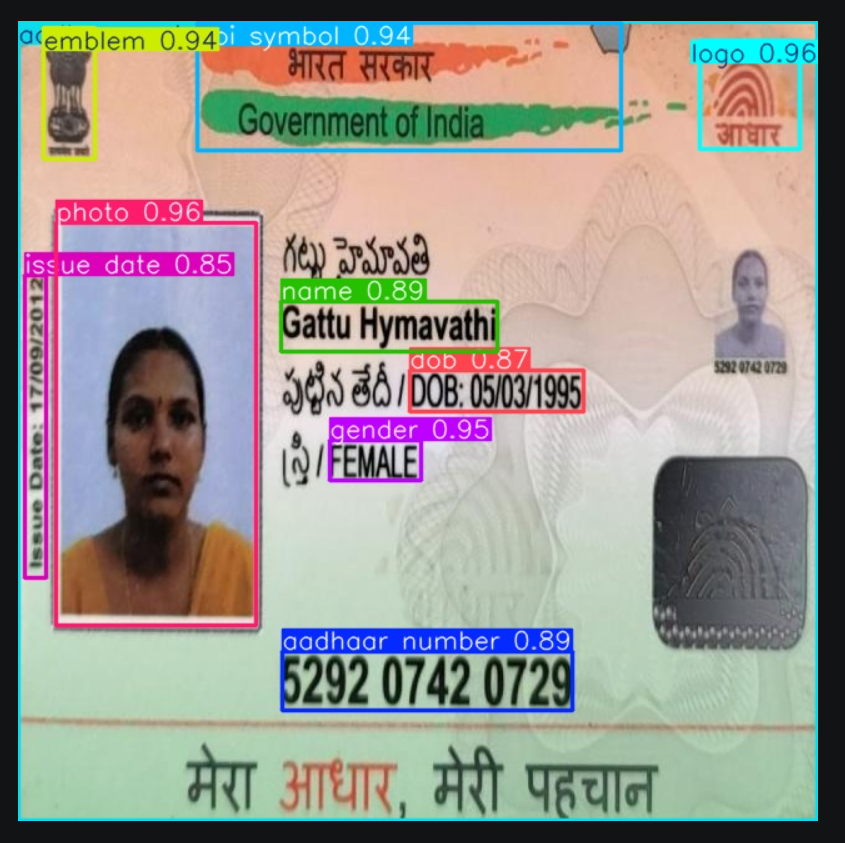

In [9]:
# Put the path to ANY image you want to test here
TEST_IMAGE = r"C:/id_card/Data/Driving License project.v1i.yolov8/test/images/dl111_jpg.rf.639d07971194dbc16010ad4ca101bf05.jpg"

# Run the analysis!
analyze_id_card(TEST_IMAGE, MY_WEIGHTS)

Loading model...
Analyzing document...

0: 608x800 1 address, 1 dl_card, 1 dl_no, 1 dob, 1 name, 1 relation_with, 1 state, 1 vehicle_type, 39.8ms
Speed: 4.4ms preprocess, 39.8ms inference, 2.3ms postprocess per image at shape (1, 3, 608, 800)
Results saved to C:\id_card\runs\detect\predict-3

🔍 DOCUMENT IDENTIFIED: Dl Card
Fields Detected:
  • vehicle_type (Confidence: 0.93)
  • dl_no (Confidence: 0.90)
  • dob (Confidence: 0.86)
  • relation_with (Confidence: 0.84)
  • name (Confidence: 0.79)
  • address (Confidence: 0.78)
  • state (Confidence: 0.72)



<Figure size 1000x1000 with 1 Axes>

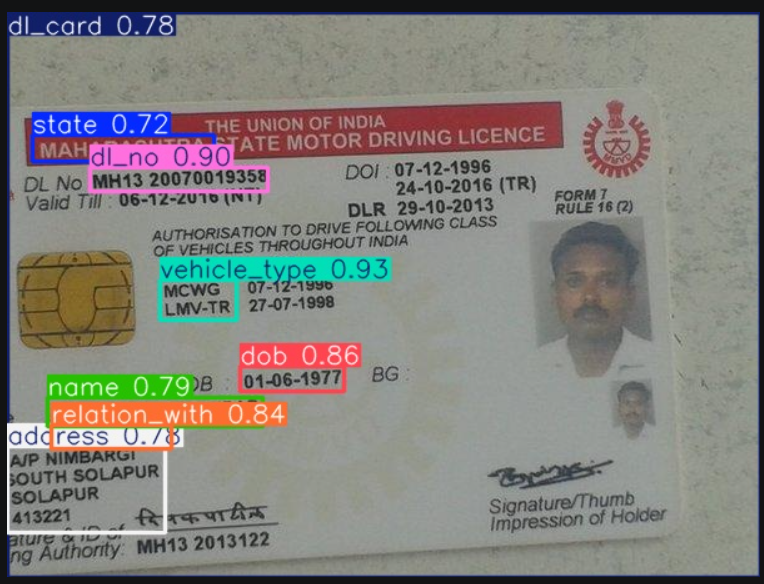